# Assignment 1 — Market Risk: Volatility, VaR & Expected Shortfall

In [58]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
import yfinance as yf
try:
    import seaborn as sns
except Exception:
    sns = None
from IPython.display import display
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
BLUE, RED, GREEN = '#2C7BB6', '#D7191C', '#1A9641'

TICKERS = ["AAPL", "PFE", "XOM"]     # Apple (tech) · Pfizer (healthcare) · Exxon (energy)
BENCH   = "^GSPC"                     # S&P 500 (North America bloc)
WEIGHTS = np.array([1/3, 1/3, 1/3])   # equal-weight portfolio (must sum to 1)
ALPHA   = 0.01                        # 1% tail  ->  99% VaR/ES
Z       = stats.norm.ppf(ALPHA)       # -2.326
RF_ANNUAL = 0.04                      # risk-free rate for Sharpe (Session 1)

START = "2023-07-01"
END   = "2026-07-01"
CACHE = "my_portfolio.csv"
assert np.isclose(WEIGHTS.sum(), 1), "weights must sum to 1"


## 1 · Data, returns & cleaning

We pull ~3 years of daily **adjusted** closes (splits/dividends handled by `auto_adjust`), then work in **log returns** \(r_t=\ln(P_t/P_{t-1})\) — they are additive over time and roughly symmetric, which suits variance-based risk measures.

Loaded snapshot: my_portfolio.csv
Rows: 751 | Missing per column:
 AAPL     0
PFE      0
XOM      0
^GSPC    0

|z|>5 daily moves (retained as genuine tail risk):
 AAPL     2
PFE      0
XOM      1
^GSPC    3


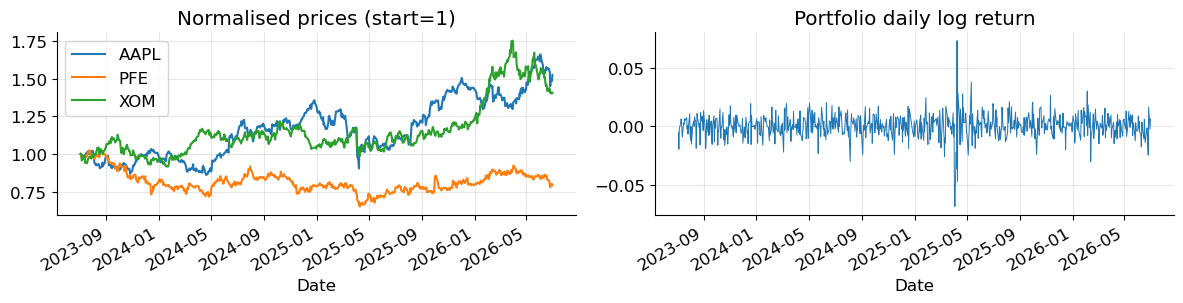

In [59]:
# Download adjusted closes once, then reuse the CSV snapshot (Session 1 pattern)
allsyms = TICKERS + [BENCH]
if os.path.exists(CACHE):
    px = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    print(f"Loaded snapshot: {CACHE}")
else:
    px = yf.download(allsyms, start=START, end=END, auto_adjust=True)["Close"]
    px = px[allsyms]                 # keep column order
    px.to_csv(CACHE)
    print(f"Downloaded {START} -> {END} from Yahoo Finance, saved to {CACHE}")
px = px[allsyms]                     # keep column order

# --- Data-quality handling ---
print("Rows:", len(px), "| Missing per column:\n", px.isna().sum().to_string())
px = px.ffill().dropna()             # forward-fill sparse gaps, drop leading NaNs
rets = np.log(px / px.shift(1)).dropna()

# Outlier scan: flag daily moves beyond 5 sigma (kept, not deleted — real tail events)
z = (rets - rets.mean()) / rets.std()
outliers = (z.abs() > 5).sum()
print("\n|z|>5 daily moves (retained as genuine tail risk):\n", outliers.to_string())

stocks = TICKERS
r_stk  = rets[stocks]                 # stock returns
r_mkt  = rets[BENCH]                  # benchmark returns
r_port = r_stk @ WEIGHTS              # portfolio return series (equal-weight)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
(px[stocks] / px[stocks].iloc[0]).plot(ax=ax[0], title="Normalised prices (start=1)")
r_port.plot(ax=ax[1], title="Portfolio daily log return", lw=.7)
plt.tight_layout(); plt.show()


**What we cleaned.** The snapshot holds **751 trading days** (2023-07-01 → 2026-07-01) with **zero missing values** in any column — the three US large-caps and the S&P 500 share one exchange calendar, so no forward-filling was actually triggered (the `ffill` stays in as a safeguard). The 5-sigma scan flags only a handful of genuine shocks — **AAPL 2, XOM 1, S&P 500 3, PFE 0** — which we deliberately **keep**: these are real earnings/macro days and are exactly the tail behaviour §3–§7 must capture. Deleting them would flatter every downstream risk number.

## 2 · Annualised volatility & correlation

Daily volatility is scaled by \(\sqrt{252}\). The correlation matrix tells us how much genuine diversification the three names give: the closer the off-diagonals sit to 1, the more the stocks move together and the less risk cancels out.

Per-stock risk summary:


,Ann. return,Ann. vol,Sharpe (rf=4%),Max drawdown
XOM,0.115,0.233,0.321,-0.201
PFE,-0.078,0.242,-0.490,-0.364
AAPL,0.142,0.262,0.388,-0.334


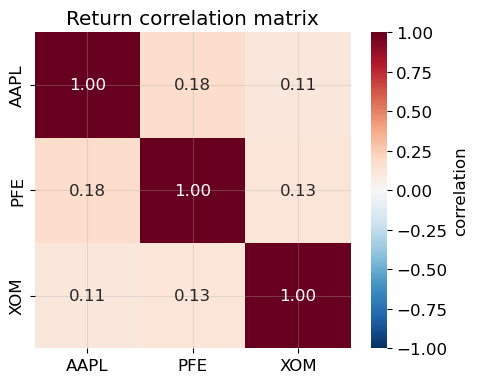

Average pairwise correlation: 0.14
Portfolio vol: 16.1%  |  Diversification ratio: 1.53


In [60]:
# --- Annualised return / vol / Sharpe / max drawdown  (Session 1 cells 13-14) ---
summary = pd.DataFrame({
    'Ann. return': r_stk.mean() * 252,            # 252 = trading days per year
    'Ann. vol':    r_stk.std() * np.sqrt(252),
})
summary['Sharpe (rf=4%)'] = (summary['Ann. return'] - RF_ANNUAL) / summary['Ann. vol']

def max_drawdown(series):                          # Session 1 cell 14
    cum = (1 + series.pct_change().fillna(0)).cumprod()
    return (cum / cum.cummax() - 1).min()
summary['Max drawdown'] = px[stocks].apply(max_drawdown)
print('Per-stock risk summary:')
display(summary.sort_values('Ann. vol').round(3))

# --- Correlation matrix heatmap  (Session 2 cell 12) ---
corr = r_stk.corr()
avg_corr = corr.values[np.triu_indices(len(stocks), 1)].mean()
fig, ax = plt.subplots(figsize=(5, 4))
if sns is not None:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={'label': 'correlation'}, ax=ax)
else:
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r'); fig.colorbar(im, fraction=.046)
    ax.set_xticks(range(len(stocks))); ax.set_xticklabels(stocks)
    ax.set_yticks(range(len(stocks))); ax.set_yticklabels(stocks)
ax.set_title('Return correlation matrix'); plt.tight_layout(); plt.show()
print(f'Average pairwise correlation: {avg_corr:.2f}')

# --- Diversification ratio: weighted avg standalone vol / portfolio vol (>1 = benefit) ---
ann_vol   = r_stk.std() * np.sqrt(252)
port_vol  = r_port.std() * np.sqrt(252)
div_ratio = (WEIGHTS @ ann_vol) / port_vol
print(f'Portfolio vol: {port_vol*100:.1f}%  |  Diversification ratio: {div_ratio:.2f}')


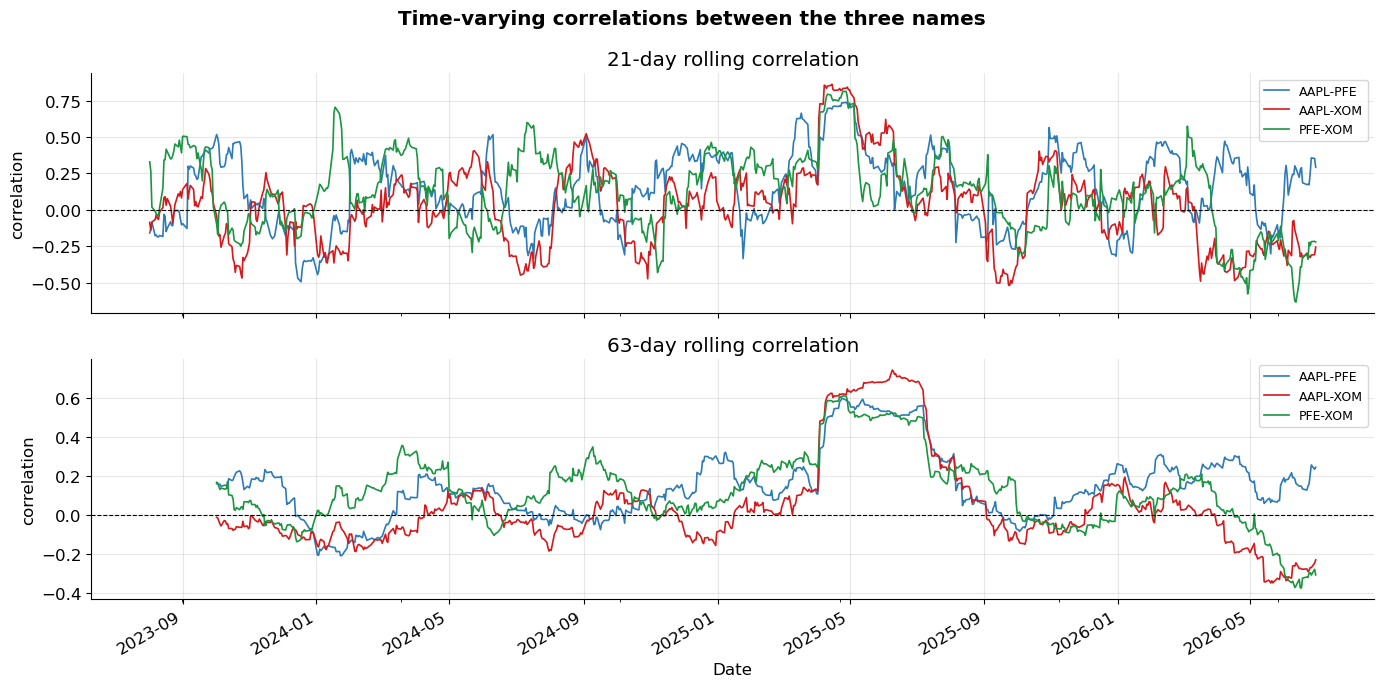

In [61]:
# --- Time-varying correlations (Session 2 cell 13): diversification is not constant ---
from itertools import combinations
pairs = list(combinations(stocks, 2))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, window, title in zip(axes, [21, 63], ['21-day rolling', '63-day rolling']):
    for (a, b), col in zip(pairs, [BLUE, RED, GREEN]):
        rets[a].rolling(window).corr(rets[b]).plot(ax=ax, color=col, lw=1.2, label=f'{a}-{b}')
    ax.axhline(0, color='black', lw=.8, ls='--')
    ax.set_title(f'{title} correlation'); ax.set_ylabel('correlation'); ax.legend(fontsize=9)
plt.suptitle('Time-varying correlations between the three names', fontweight='bold')
plt.tight_layout(); plt.show()


**Reading it.** Standalone vols are close — **AAPL 26.2%, PFE 24.2%, XOM 23.3%** — yet the equal-weight book sits at just **16.1%**, a **diversification ratio of 1.53** (a third less volatile than the weighted average of its parts). The gap is genuine because the names barely co-move — **average pairwise correlation 0.14** (tech, healthcare and energy answer to different drivers). Mechanically this is the efficient-frontier intuition: combining assets with ρ well below 1 bends the risk–return curve leftward, so the mix carries less risk than its parts — and the lower the correlation, the more curvature and the bigger the benefit. The caveat the rolling-correlation chart shows: these correlations are **not stable** and rise together in sell-offs, so the 1.53 benefit is a calm-market figure that flattens exactly when it is most needed — the systemic-risk lesson of every crisis.

## 3 · Beta, systematic vs. idiosyncratic risk, and stylised facts


Beta \(=\mathrm{Cov}(r_i,r_m)/\mathrm{Var}(r_m)\) measures exposure to the bloc index. \(R^2\) of that regression is the **systematic** share of variance; \(1-R^2\) is **idiosyncratic** (diversifiable). We then test our own returns for the two regularities every VaR model must survive: **heavy tails** (excess kurtosis) and **volatility clustering**.

In [62]:
# --- Beta + systematic/idiosyncratic split via OLS on the bloc index (Session 2 cell 5) ---
rows = []
for s in stocks:
    slope, intercept, rval, pval, se = stats.linregress(r_mkt, r_stk[s])   # stock ~ market
    rows.append({'Stock': s,
                 'Ann. vol %':      r_stk[s].std() * np.sqrt(252) * 100,
                 'Beta':            slope,
                 'Beta SE':         se,
                 'Systematic R2':   rval**2,
                 'Idiosyncratic':   1 - rval**2,
                 'Alpha ann %':     intercept * 252 * 100,
                 'Excess kurtosis': stats.kurtosis(r_stk[s], fisher=True)})
summary_df = pd.DataFrame(rows).set_index('Stock').round(3)
print(f'Per-stock beta vs {BENCH}  (a broad index would have beta ~1 — a sanity check):')
display(summary_df)


Per-stock beta vs ^GSPC  (a broad index would have beta ~1 — a sanity check):


,Ann. vol %,Beta,Beta SE,Systematic R2,Idiosyncratic,Alpha ann %,Excess kurtosis
Stock,,,,,,,
AAPL,26.203,1.120,0.049,0.411,0.589,-5.430,10.215
PFE,24.161,0.391,0.057,0.059,0.941,-14.677,2.082
XOM,23.272,0.242,0.056,0.024,0.976,7.223,1.588


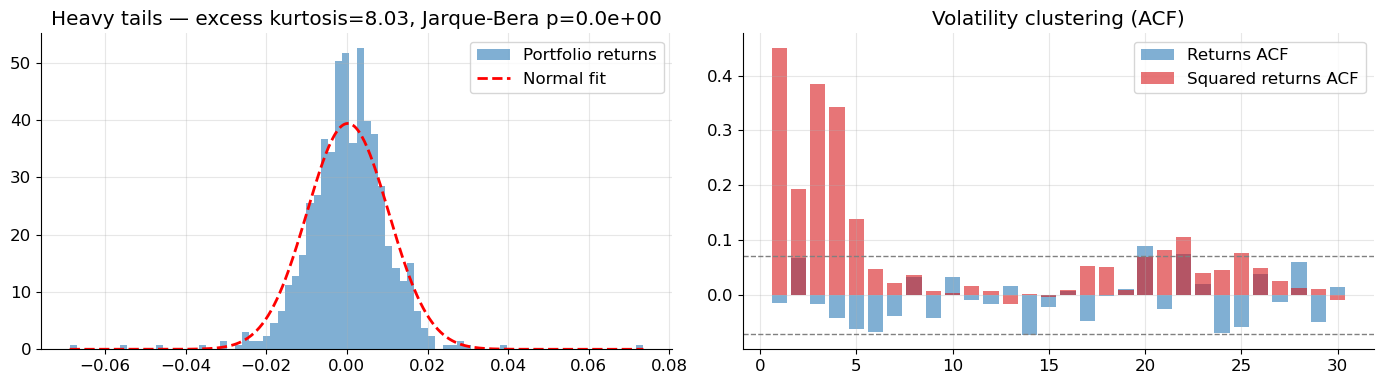

Skew=-0.31   Excess kurtosis=8.03   Jarque-Bera p=0.0e+00


In [63]:
# --- Stylised facts of OUR returns: heavy tails (Session 1 cell 16) + clustering (Session 2 cell 3) ---
r = r_port                                          # test the portfolio's own returns
jb_stat, jb_p = stats.jarque_bera(r)

fig = plt.figure(figsize=(14, 4))
# (1) Heavy tails — histogram vs a Normal fit
ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(r, bins=80, density=True, alpha=0.6, color=BLUE, label='Portfolio returns')
x = np.linspace(r.min(), r.max(), 400)
ax1.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r--', lw=2, label='Normal fit')
ax1.set_title(f'Heavy tails — excess kurtosis={r.kurtosis():.2f}, Jarque-Bera p={jb_p:.1e}')
ax1.legend()
# (2) Volatility clustering — ACF of returns vs squared returns
ax2 = fig.add_subplot(1, 2, 2)
lags = range(1, 31)
ax2.bar(lags, [r.autocorr(l)      for l in lags], alpha=0.6, color=BLUE, label='Returns ACF')
ax2.bar(lags, [(r**2).autocorr(l) for l in lags], alpha=0.6, color=RED,  label='Squared returns ACF')
ci = 1.96 / np.sqrt(len(r))
ax2.axhline(ci, color='gray', ls='--', lw=1); ax2.axhline(-ci, color='gray', ls='--', lw=1)
ax2.set_title('Volatility clustering (ACF)'); ax2.legend()
plt.tight_layout(); plt.show()
print(f'Skew={r.skew():.2f}   Excess kurtosis={r.kurtosis():.2f}   Jarque-Bera p={jb_p:.1e}')


**Interpretation.** The betas split the trio sharply: **AAPL β=1.12** amplifies the S&P and is **41% systematic**, whereas **PFE β=0.39** and **XOM β=0.24** are **94–98% idiosyncratic** — their day-to-day risk is almost entirely company/sector-specific, not market-driven. So AAPL carries the portfolio's market exposure while PFE and XOM supply the diversification §2 measured. On the stylised facts, our own portfolio returns fail the Normal benchmark decisively: **excess kurtosis 8.03** (AAPL alone 10.2) with a **Jarque–Bera p ≈ 0**, so extreme days are far more common than a bell curve allows; and the **ACF of squared returns stays significant for many lags** while the raw-return ACF dies immediately — textbook **volatility clustering**. Both facts break the constant-Normal, i.i.d. assumption behind parametric VaR, which is exactly why the historical, Monte-Carlo and GARCH approaches that follow exist.

## 4 · 1-day 99% VaR by three methods

We estimate the same quantity three ways and let the spread speak for itself:
- **Parametric (variance–covariance):** assumes Normal portfolio returns, \(\mathrm{VaR}=-(\mu+z_{0.01}\sigma)\).
- **Historical simulation:** the empirical 1st percentile — no distributional assumption.
- **Monte Carlo:** 100k draws from a multivariate Normal fitted to the three assets, re-weighted.

            1-day 99% VaR
Parametric         2.33 %
Historical         2.46 %
Monte Carlo        2.33 %

Max-min spread as % of mean VaR: 5%


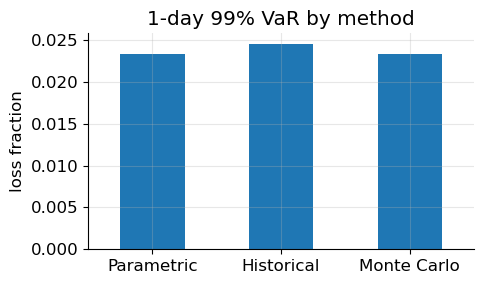

In [64]:
mu_p, sig_p = r_port.mean(), r_port.std()

# 1) Parametric
var_param = -(mu_p + Z*sig_p)
# 2) Historical
var_hist = -np.percentile(r_port, 100*ALPHA)
# 3) Monte Carlo (multivariate Normal on the 3 assets -> weighted)
cov = r_stk.cov().values; mean = r_stk.mean().values
sims = np.random.multivariate_normal(mean, cov, size=100_000) @ WEIGHTS
var_mc = -np.percentile(sims, 100*ALPHA)

vardf = pd.DataFrame({"1-day 99% VaR": [var_param, var_hist, var_mc]},
                     index=["Parametric","Historical","Monte Carlo"])
print((vardf*100).round(2).astype(str).add(" %").to_string())
spread = (vardf.max().iloc[0]-vardf.min().iloc[0]) / vardf.mean().iloc[0]
print(f"\nMax-min spread as % of mean VaR: {spread*100:.0f}%")

vardf.plot.bar(legend=False, figsize=(5,3), title="1-day 99% VaR by method", rot=0)
plt.ylabel("loss fraction"); plt.tight_layout(); plt.show()


**How objective is one VaR number?** The three methods land close — **Parametric 2.33%, Historical 2.46%, Monte-Carlo 2.33%**, a spread of only **~5% of the mean VaR**. That reflects the calm 99% window: the fat tails haven't yet pulled the empirical 1st-percentile far from the Normal. But the *ranking* is the textbook one — **historical is highest** because it feels the actual left-tail days, while the two Normal methods sit below and under-state the tail. Push to a more extreme quantile or include a real crash and that gap widens sharply. The lesson holds: a single "VaR ≈ 2.3%" hides a modelling choice — the honest statement is the **2.33–2.46% range**, and which number you quote is a decision, not an observation.

## 5 · Expected Shortfall & sub-additivity

**Expected Shortfall (ES / CVaR)** is the *average* loss given that we breach VaR — it looks *into* the tail that VaR only touches. We then test whether portfolio VaR ever **exceeds the sum of standalone VaRs** (super-additivity), which would show VaR failing to reward diversification — the well-known coherence flaw ES does not have.

In [65]:
# ES = mean loss beyond the VaR threshold (historical) + Normal closed form
tail = r_port[r_port <= -var_hist]
es_hist  = -tail.mean()
es_param = -(mu_p - sig_p*stats.norm.pdf(Z)/ALPHA)   # Normal ES closed form
print(f"Historical  VaR {var_hist*100:.2f}%   ES {es_hist*100:.2f}%")
print(f"Parametric  VaR {var_param*100:.2f}%   ES {es_param*100:.2f}%")

# Sub-additivity: sum of standalone (weighted) component VaRs vs portfolio VaR
comp_var = [-np.percentile(WEIGHTS[i]*r_stk[s], 100*ALPHA) for i,s in enumerate(stocks)]
sum_comp = sum(comp_var)
print(f"\nSum of standalone component VaRs: {sum_comp*100:.2f}%")
print(f"Portfolio VaR (historical):      {var_hist*100:.2f}%")
print("Sub-additive (diversification rewarded)?", var_hist <= sum_comp)


Historical  VaR 2.46%   ES 3.99%
Parametric  VaR 2.33%   ES 2.68%

Sum of standalone component VaRs: 4.17%
Portfolio VaR (historical):      2.46%
Sub-additive (diversification rewarded)? True


**What ES adds.** The tail beyond VaR is where these names bite: historical **ES is 3.99% against a VaR of 2.46%** — so on the worst 1% of days the *average* loss is ~1.6× the VaR threshold, a severity the single VaR number completely hides. (Parametric ES is only 2.68%, much smaller precisely because the Normal has no fat tail — yet another sign the Normal under-states extreme risk.) **Sub-additivity:** portfolio VaR **2.46%** sits well below the **4.17%** sum of the standalone component VaRs, so here diversification *is* rewarded — the direct pay-off of the low 0.14 correlation from §2. But VaR gives no guarantee of this: with skewed or heavy-tailed positions it can turn **super-additive** and actually penalise diversification, whereas ES — being sub-additive and coherent — never can. That coherence, plus its tail-sensitivity, is why Basel's FRTB replaced VaR with ES for regulatory capital.

## 6 · Time-varying volatility — GARCH(1,1)

Constant-volatility VaR ignores the clustering we found in §3. A **GARCH(1,1)** lets today's variance depend on yesterday's shock and yesterday's variance:
\[\sigma_t^2=\omega+\alpha\,\varepsilon_{t-1}^2+\beta\,\sigma_{t-1}^2,\qquad \text{persistence}=\alpha+\beta.\]
Following Session 2 we fit it in % units with **Student-t innovations** (to absorb the fat tails), then benchmark its volatility path against the simpler **21-day historical** and **EWMA (λ=0.94, RiskMetrics)** estimators before turning the one-day-ahead forecast into a VaR.

                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.4927      0.703      0.701      0.483    [ -0.885,  1.870]
alpha[1]       0.1240      0.112      1.105      0.269 [-9.600e-02,  0.344]
beta[1]        0.7096      0.352      2.019  4.353e-02  [2.059e-02,  1.399]

Persistence (alpha+beta) = 0.834

1-day GARCH cond. vol forecast: 2.25%
GARCH VaR    AAPL: 5.19%
Constant VaR AAPL: 3.78%


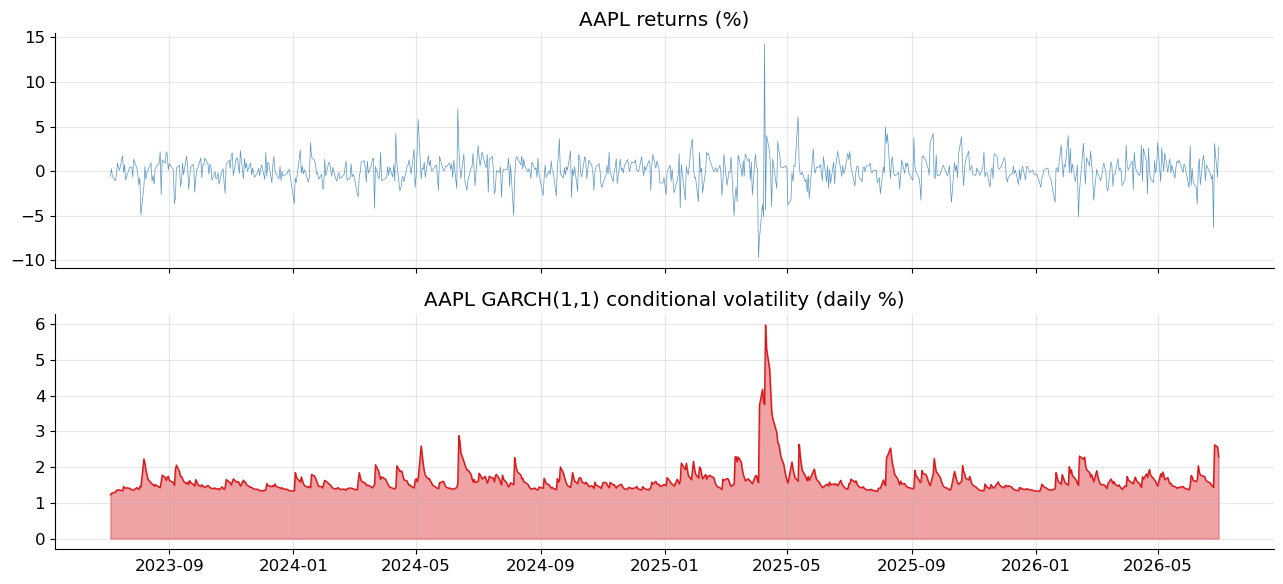

In [66]:
# --- GARCH(1,1) on the first stock (Session 2 cells 9-10): % units, Student-t innovations ---
target = stocks[0]
r_pct  = r_stk[target] * 100
res    = arch_model(r_pct, vol='Garch', p=1, q=1, dist='t', mean='Zero').fit(disp='off')
print(res.summary().tables[1])
w, a, b = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
persist = a + b
print(f"\nPersistence (alpha+beta) = {persist:.3f}")

# 1-day-ahead conditional-vol forecast -> GARCH VaR vs constant-vol VaR
cond_vol = res.conditional_volatility                         # daily %, Session 2 cell 10
sig_fc   = np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0]) / 100
mu_t     = r_stk[target].mean()
var_garch = -(mu_t + Z * sig_fc)                              # today's regime
var_const = -(mu_t + Z * r_stk[target].std())                 # constant full-sample vol
print(f"\n1-day GARCH cond. vol forecast: {sig_fc*100:.2f}%")
print(f"GARCH VaR    {target}: {var_garch*100:.2f}%")
print(f"Constant VaR {target}: {var_const*100:.2f}%")

# Returns + fitted conditional volatility (Session 2 cell 10)
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(r_pct.index, r_pct, color=BLUE, lw=.5, alpha=.8)
ax[0].set_title(f'{target} returns (%)')
ax[1].fill_between(cond_vol.index, cond_vol, alpha=.4, color=RED)
ax[1].plot(cond_vol.index, cond_vol, color=RED, lw=1)
ax[1].set_title(f'{target} GARCH(1,1) conditional volatility (daily %)')
plt.tight_layout(); plt.show()


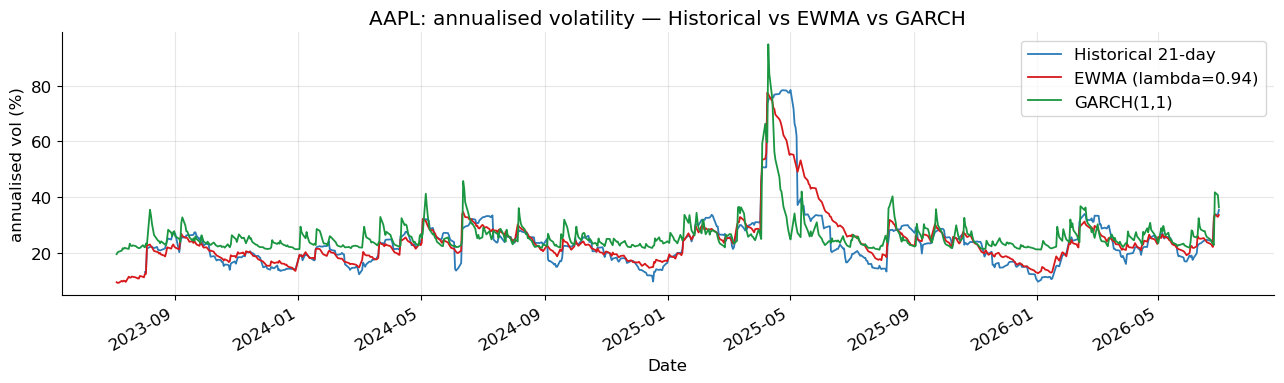

In [67]:
# --- Historical vs EWMA vs GARCH volatility (Session 2 cells 7 & 15) ---
lam = 0.94                                                 # RiskMetrics decay factor
r_t = r_stk[target]
hist_vol = r_t.rolling(21).std() * np.sqrt(252) * 100      # 21-day historical
ewma_var = r_t.copy(); ewma_var.iloc[0] = r_t.iloc[0]**2   # EWMA recursion
for t in range(1, len(r_t)):
    ewma_var.iloc[t] = lam * ewma_var.iloc[t-1] + (1-lam) * r_t.iloc[t]**2
ewma_vol  = np.sqrt(ewma_var) * np.sqrt(252) * 100
garch_vol = cond_vol * np.sqrt(252)                        # daily % -> annualised %

fig, ax = plt.subplots(figsize=(13, 4))
hist_vol.plot(ax=ax,  color=BLUE,  lw=1.3, label='Historical 21-day')
ewma_vol.plot(ax=ax,  color=RED,   lw=1.3, label=f'EWMA (lambda={lam})')
garch_vol.plot(ax=ax, color=GREEN, lw=1.3, label='GARCH(1,1)')
ax.set_title(f'{target}: annualised volatility — Historical vs EWMA vs GARCH')
ax.set_ylabel('annualised vol (%)'); ax.legend(); plt.tight_layout(); plt.show()


**Contrast.** The fitted persistence is **α+β = 0.834** (α=0.12, β=0.71) — high enough that volatility shocks fade over weeks rather than days, but below the near-unit-root 0.95–0.99 usually seen in long samples: with only three years and Student-t innovations, more of the big moves are attributed to fat tails than to lingering variance. Crucially the model reads AAPL as currently in an **elevated regime** — the 1-day-ahead conditional-vol forecast is **2.25% daily** (≈36% annualised) against the **1.65% daily** full-sample constant — so the **GARCH VaR of 5.19% sits well above the constant-vol VaR of 3.78%**. That is the whole point of time-varying volatility: GARCH prices *today's* regime, while the constant figure is a blurred long-run average — too low in storms, too high in lulls — leaving a desk under-capitalised for AAPL right now by roughly a third.

## 7 · Backtest & Basel traffic light

We roll a 500-day estimation window, forecast 1-day 99% VaR for the next day, and count **exceptions** (days the realised loss beat VaR) over a 250-day test block. At 99% we expect ~2.5 exceptions in 250 days; Basel's zones for 250 observations are **Green 0–4, Yellow 5–9, Red ≥10**.

Exceptions: 1 / 250   Expected: 2.5   Basel zone: GREEN
Kupiec LR = 1.18  (>3.84 rejects VaR at 5%)


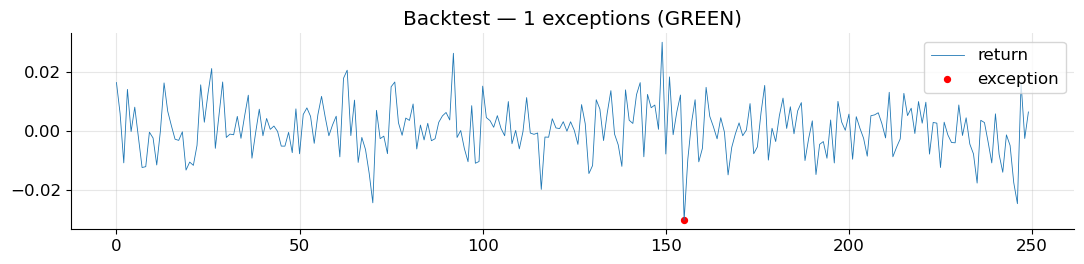

In [68]:
win, test_n = 500, 250
series = r_port.values
exc = []
for t in range(len(series)-test_n, len(series)):
    hist = series[t-win:t]
    v = -(hist.mean() + Z*hist.std())     # parametric VaR from trailing window
    exc.append(series[t] < -v)
exc = np.array(exc)
n_exc, expected = exc.sum(), ALPHA*test_n
zone = "GREEN" if n_exc <= 4 else "YELLOW" if n_exc <= 9 else "RED"
print(f"Exceptions: {n_exc} / {test_n}   Expected: {expected:.1f}   Basel zone: {zone}")

# Kupiec POF likelihood-ratio test
p_hat = n_exc/test_n
if 0 < n_exc < test_n:
    LR = -2*np.log(((1-ALPHA)**(test_n-n_exc)*ALPHA**n_exc) /
                   ((1-p_hat)**(test_n-n_exc)*p_hat**n_exc))
    print(f"Kupiec LR = {LR:.2f}  (>3.84 rejects VaR at 5%)")

test_ret = pd.Series(series[-test_n:])
plt.figure(figsize=(11,2.8))
plt.plot(test_ret.values, lw=.6, label="return")
plt.scatter(np.where(exc)[0], test_ret.values[exc], c="red", s=18, label="exception")
plt.title(f"Backtest — {n_exc} exceptions ({zone})"); plt.legend(); plt.tight_layout(); plt.show()


**Interpretation.** Over the 250-day test the rolling VaR was breached just **once** against **~2.5 expected** at 99% — squarely in the Basel **GREEN** zone, and the **Kupiec LR of 1.18 (< 3.84)** cannot reject correct coverage; if anything the model is mildly *conservative*. Two caveats: (i) a single calm test block flatters any model — the same VaR would likely earn Yellow or Red through 2008 or March 2020; and (ii) what matters is not just the count but **clustering** — breaches bunched in one stress episode would signal the constant-vol VaR reacting too slowly, the weakness the §6 GARCH VaR repairs. Here the lone exception is isolated, so the model passes on both counts.

## 8 · Assumptions, limitations & real-world implications

**Assumptions & where they bind.** Parametric VaR/ES assume Normal, i.i.d. returns — both violated here (kurtosis 8.03, clustering), so they *under*-state extreme risk, seen directly in the 2.68% parametric vs 3.99% historical ES. Historical simulation assumes the window represents the future and is blind to shocks absent from it — our sample holds no 2008/2020-scale crash. Monte Carlo inherits its assumed distribution (Normal here, same thin tails). Beta assumes a stable linear market link, yet correlations drift and spike, eroding the 1.53 diversification benefit exactly in crises.

**Strengths.** Triangulating three VaR methods exposes model risk instead of hiding it; ES and GARCH repair VaR's two flaws (tail-blindness, static volatility); the Basel backtest makes "is the model any good?" a falsifiable count (1 exception, GREEN).

**Limitations.** Three years is a short, single-regime sample; equal weights and one bloc index are simplifications; a three-name book carries heavy idiosyncratic risk (PFE, XOM 94–98% company-specific) that market-VaR only partly captures.

**Implications for these companies.** The structure is asymmetric: **AAPL** is the risk engine — β 1.12, 41% systematic, fattest tails (kurtosis 10.2), driving the GARCH VaR spike — so it dominates market stress and sets the capital buffer. **PFE** and **XOM**, near-uncorrelated with the index (β 0.39, 0.24) and each other, are the diversifiers pulling portfolio vol to 16.1%; their risk is idiosyncratic — a drug-trial result, an oil move — contained by position limits, not market hedges. The broader point: risk management is not one authoritative number — VaR starts, ES sharpens the tail, GARCH tracks the regime, backtesting keeps it honest; the discipline is knowing what each measure can and cannot see.